# 3DBreastNet - 128x128x128 Voxel Reconstruction

## 1. Install Dependencies

In [2]:
!uv pip install torch torchvision tifffile opencv-python numpy scipy scikit-image matplotlib tqdm pandas

Using Python 3.11.9 environment at: /mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/.venv
Checked 10 packages in 23ms


In [3]:
# tqdm.notebook is provided by tqdm; ipywidgets enables the notebook progress UI.
!uv pip install tqdm ipywidgets

Using Python 3.11.9 environment at: /mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/.venv
Checked 2 packages in 5ms


## 2. Model Definitions

In [12]:
"""3DBreastNet — Model definitions (128³ voxel grid)."""
import math, torch, torch.nn as nn, torch.nn.functional as F

# ── Building blocks ──────────────────────────────────────────
class DoubleConv2D(nn.Module):
    def __init__(self, inc, outc, drop=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(inc, outc, 3, padding=1, bias=False),
            nn.BatchNorm2d(outc), nn.ReLU(True),
            nn.Dropout2d(drop) if drop > 0 else nn.Identity(),
            nn.Conv2d(outc, outc, 3, padding=1, bias=False),
            nn.BatchNorm2d(outc), nn.ReLU(True))
    def forward(self, x): return self.block(x)

class DoubleConv3D(nn.Module):
    def __init__(self, inc, outc, drop=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(inc, outc, 3, padding=1, bias=False),
            nn.BatchNorm3d(outc), nn.ReLU(True),
            nn.Dropout3d(drop) if drop > 0 else nn.Identity(),
            nn.Conv3d(outc, outc, 3, padding=1, bias=False),
            nn.BatchNorm3d(outc), nn.ReLU(True))
    def forward(self, x): return self.block(x)

def _init(m):
    if isinstance(m, (nn.Conv2d, nn.Conv3d, nn.ConvTranspose2d, nn.ConvTranspose3d)):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None: nn.init.constant_(m.bias, 0)
    elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm3d)):
        nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None: nn.init.constant_(m.bias, 0)

# ── U-Net (for mask generation, frozen) ──────────────────────
class DoubleConv(nn.Module):
    def __init__(self, inc, outc, drop=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(inc, outc, 3, padding=1, bias=False),
            nn.BatchNorm2d(outc), nn.ReLU(True),
            nn.Conv2d(outc, outc, 3, padding=1, bias=False),
            nn.BatchNorm2d(outc), nn.ReLU(True),
            nn.Dropout2d(drop) if drop > 0 else nn.Identity())
    def forward(self, x): return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_c=1, out_c=1, b=64, drop=0.2):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.enc1 = DoubleConv(in_c, b, 0.0)
        self.enc2 = DoubleConv(b, b*2, 0.0)
        self.enc3 = DoubleConv(b*2, b*4, 0.1)
        self.enc4 = DoubleConv(b*4, b*8, 0.1)
        self.bottleneck = DoubleConv(b*8, b*16, drop)
        self.up4 = nn.ConvTranspose2d(b*16, b*8, 2, stride=2)
        self.dec4 = DoubleConv(b*16, b*8, 0.1)
        self.up3 = nn.ConvTranspose2d(b*8, b*4, 2, stride=2)
        self.dec3 = DoubleConv(b*8, b*4, 0.1)
        self.up2 = nn.ConvTranspose2d(b*4, b*2, 2, stride=2)
        self.dec2 = DoubleConv(b*4, b*2, 0.0)
        self.up1 = nn.ConvTranspose2d(b*2, b, 2, stride=2)
        self.dec1 = DoubleConv(b*2, b, 0.0)
        self.out = nn.Conv2d(b, out_c, 1)
    def forward(self, x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1))
        e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.bottleneck(self.pool(e4))
        d4=self.dec4(torch.cat([self.up4(b),e4],1))
        d3=self.dec3(torch.cat([self.up3(d4),e3],1))
        d2=self.dec2(torch.cat([self.up2(d3),e2],1))
        d1=self.dec1(torch.cat([self.up1(d2),e1],1))
        return self.out(d1)

# ── Encoder 2D  (5×128×128 → 1000-d latent) ─────────────────
class Encoder2D(nn.Module):
    def __init__(self, drop=0.25):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.enc1 = DoubleConv2D(5, 32, 0)
        self.enc2 = DoubleConv2D(32, 64, 0)
        self.enc3 = DoubleConv2D(64, 128, drop)
        self.enc4 = DoubleConv2D(128, 256, drop)
        self.enc5 = DoubleConv2D(256, 512, drop)
        self.enc6 = DoubleConv2D(512, 512, drop)
        self.fc = nn.Sequential(nn.Dropout(drop), nn.Linear(512*2*2, 1000))
        self.apply(_init)
    def forward(self, x):
        for enc in [self.enc1, self.enc2, self.enc3, self.enc4, self.enc5, self.enc6]:
            x = enc(x); x = self.pool(x)
        return self.fc(x.view(x.size(0), -1))

# ── Decoder 3D  (1000-d → 1×128×128×128) with grad-checkpoint
class Decoder3D(nn.Module):
    def __init__(self, drop=0.25):
        super().__init__()
        self.fc = nn.Linear(1000, 512*2*2*2)
        self.up1=nn.ConvTranspose3d(512,256,2,stride=2); self.d1=DoubleConv3D(256,256,drop)
        self.up2=nn.ConvTranspose3d(256,128,2,stride=2); self.d2=DoubleConv3D(128,128,drop)
        self.up3=nn.ConvTranspose3d(128,64,2,stride=2);  self.d3=DoubleConv3D(64,64,drop)
        self.up4=nn.ConvTranspose3d(64,32,2,stride=2);   self.d4=DoubleConv3D(32,32,0)
        self.up5=nn.ConvTranspose3d(32,16,2,stride=2);   self.d5=DoubleConv3D(16,16,0)
        self.up6=nn.ConvTranspose3d(16,8,2,stride=2);    self.d6=DoubleConv3D(8,8,0)
        self.out = nn.Sequential(nn.Conv3d(8,1,1), nn.Sigmoid())
        self.apply(_init)
        nn.init.constant_(self.out[0].bias, -4.0)   # start near-empty

    def _s4(self, x): return self.d4(self.up4(x))
    def _s5(self, x): return self.d5(self.up5(x))
    def _s6(self, x): return self.d6(self.up6(x))

    def forward(self, x):
        x = self.fc(x).view(x.size(0), 512, 2, 2, 2)
        x = self.d1(self.up1(x))
        x = self.d2(self.up2(x))
        x = self.d3(self.up3(x))
        if x.requires_grad:
            x = torch.utils.checkpoint.checkpoint(self._s4, x, use_reentrant=False)
            x = torch.utils.checkpoint.checkpoint(self._s5, x, use_reentrant=False)
            x = torch.utils.checkpoint.checkpoint(self._s6, x, use_reentrant=False)
        else:
            x = self._s4(x); x = self._s5(x); x = self._s6(x)
        return self.out(x)

# ── Differentiable projection (Eq. 1-3 from paper) ──────────
# Runs in pure float32 (isolated from autocast in train.py)
def render_projection(volume, theta_deg):
    B,C,D,H,W = volume.shape; dev = volume.device
    if not isinstance(theta_deg, torch.Tensor):
        theta_deg = torch.full((B,), float(theta_deg), device=dev, dtype=torch.float32)
    theta_deg = theta_deg.float()
    rad = theta_deg * math.pi / 180.0
    c, s = torch.cos(rad), torch.sin(rad)
    z, o = torch.zeros_like(rad), torch.ones_like(rad)
    mat = torch.stack([torch.stack([c,z,s,z],-1),
                       torch.stack([z,o,z,z],-1),
                       torch.stack([-s,z,c,z],-1)], -2)
    grid = F.affine_grid(mat, volume.shape, align_corners=False)
    Vr = F.grid_sample(volume, grid, mode='bilinear', padding_mode='zeros', align_corners=False)
    return 1.0 - torch.exp(-Vr.squeeze(1).sum(dim=1, keepdim=True))

# ── Dice loss (Eq. 7) — float32-safe ────────────────────────
def dice_loss(pred, target, eps=1e-6):
    p, t = pred.float(), target.float()
    num = 2*(p*t).sum()
    den = p.pow(2).sum() + t.pow(2).sum() + eps
    return 1 - num/den

VIEW_WINDOWS = [(-90.,-67.5),(-67.5,-22.5),(-22.5,22.5),(22.5,67.5),(67.5,90.)]


## 3. Training

In [13]:
"""3DBreastNet — Training script for 128³ voxel reconstruction.
Usage:  python train.py
"""
import os, sys, time, random, json, math
import numpy as np, cv2, tifffile, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict
from tqdm.auto import tqdm

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import scipy.ndimage

# ════════════════════════════════════════════════════════════════
# CONFIG
# ════════════════════════════════════════════════════════════════
CFG = {
    "epochs":       400,
    "batch_size":   2,
    "lr":           1e-4,
    "betas":        (0.5, 0.9),
    "n_per_view":   2,
    "seed":         42,
    "patience":     50,
    "ckpt_dir":     "checkpoints_3d",
    "tiff_base":    r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/organized_by_patient",
    "unet_ckpt":    r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/UNET_Segmentation/breast_segmentation_unet_best_gpu.pth",
}

# ════════════════════════════════════════════════════════════════
# DATA
# ════════════════════════════════════════════════════════════════
@dataclass
class PatientGroup:
    patient_id: str
    label: str
    views: Dict[str, Path]

def get_view_key(filename):
    n = filename.lower()
    if "right later" in n: return "RL"
    if "right obli"  in n: return "RO"
    if "frontal" in n or "anterior" in n: return "F"
    if "left obliq"  in n: return "LO"
    if "left later"  in n: return "LL"
    return None

def build_patient_groups(tiff_base):
    tb = Path(tiff_base)
    pd_ = {}
    for tp in tb.rglob("*.tiff"):
        parts = tp.relative_to(tb).parts
        if len(parts) < 3: continue
        pid, lab, fn = parts[0], parts[1], parts[-1]
        vk = get_view_key(fn)
        if not vk: continue
        key = (pid, lab)
        if key not in pd_: pd_[key] = {"views": {}}
        pd_[key]["views"][vk] = tp
    groups, skip, nb_, nm = [], 0, 0, 0
    for (pid, lab), d in pd_.items():
        if len(d["views"]) == 5:
            groups.append(PatientGroup(pid, lab, d["views"]))
            nb_ += lab.lower() == "benign"; nm += lab.lower() != "benign"
        else:
            print(f"  Skip {pid} ({lab}): {len(d['views'])}/5 views"); skip += 1
    groups.sort(key=lambda g: g.patient_id)
    print(f"Patients: {len(pd_)} | Complete: {len(groups)} | "
          f"Skipped: {skip} | B={nb_} M={nm}")
    return groups

class PatientDataset(Dataset):
    def __init__(self, groups, unet, device, img_sz=256):
        self.groups, self.unet, self.device = groups, unet, device
        self.img_sz = img_sz
        self.views = ["RL","RO","F","LO","LL"]
    def __len__(self): return len(self.groups)
    def __getitem__(self, idx):
        g = self.groups[idx]; thermals, masks = [], []
        for v in self.views:
            raw = tifffile.imread(str(g.views[v])).astype(np.float32)
            raw = cv2.resize(raw, (self.img_sz, self.img_sz))
            mn, mx = raw.min(), raw.max()
            norm = (raw - mn) / (mx - mn + 1e-8)
            thermals.append(norm)
            # Always use U-Net for consistent segmentation
            with torch.no_grad():
                inp = torch.tensor(norm).unsqueeze(0).unsqueeze(0).to(self.device)
                m = (torch.sigmoid(self.unet(inp)).squeeze().cpu().numpy() > 0.5).astype(np.float32)
            masks.append(cv2.resize(m, (128,128), interpolation=cv2.INTER_NEAREST))
        return {
            "masks_5ch": torch.tensor(np.stack(masks), dtype=torch.float32),
            "thermals_5ch": torch.tensor(np.stack(thermals), dtype=torch.float32),
            "patient_id": g.patient_id, "label": g.label,
        }

# ════════════════════════════════════════════════════════════════
# METRICS
# ════════════════════════════════════════════════════════════════
def hd95(p, t):
    if p.sum()==0 or t.sum()==0: return 128.0
    pe = p ^ scipy.ndimage.binary_erosion(p)
    te = t ^ scipy.ndimage.binary_erosion(t)
    dtp = scipy.ndimage.distance_transform_edt(~pe)
    dtt = scipy.ndimage.distance_transform_edt(~te)
    d1 = np.percentile(dtt[pe], 95) if pe.sum()>0 else 128.0
    d2 = np.percentile(dtp[te], 95) if te.sum()>0 else 128.0
    return max(d1, d2)

# ════════════════════════════════════════════════════════════════
# TRAIN
# ════════════════════════════════════════════════════════════════
def train(cfg):
    torch.manual_seed(cfg["seed"]); np.random.seed(cfg["seed"])
    torch.cuda.manual_seed_all(cfg["seed"])
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    # U-Net (frozen)
    unet = UNet().to(device)
    unet.load_state_dict(torch.load(cfg["unet_ckpt"], map_location=device))
    unet.eval()
    for p in unet.parameters(): p.requires_grad = False

    # Data
    groups = build_patient_groups(cfg["tiff_base"])
    rng = random.Random(cfg["seed"])
    ben = [g for g in groups if g.label.lower()=="benign"]
    mal = [g for g in groups if g.label.lower()!="benign"]
    rng.shuffle(ben); rng.shuffle(mal)
    s = 0.78
    trn = ben[:int(len(ben)*s)] + mal[:int(len(mal)*s)]
    val = ben[int(len(ben)*s):] + mal[int(len(mal)*s):]
    print(f"Train: {len(trn)} | Val: {len(val)}")

    trn_dl = DataLoader(PatientDataset(trn, unet, device),
                        batch_size=cfg["batch_size"], shuffle=True, drop_last=True)
    val_dl = DataLoader(PatientDataset(val, unet, device),
                        batch_size=cfg["batch_size"], shuffle=False)

    # Models
    enc = Encoder2D().to(device)
    dec = Decoder3D().to(device)
    opt = torch.optim.Adam(list(enc.parameters())+list(dec.parameters()),
                           lr=cfg["lr"], betas=cfg["betas"])
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="max", factor=0.5, patience=30, min_lr=1e-6)
    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
    Path(cfg["ckpt_dir"]).mkdir(parents=True, exist_ok=True)

    best_dice, no_imp = 0.0, 0
    hist = {"epoch":[], "train_loss":[], "val_loss":[], "val_dice":[], "val_hd":[]}
    val_angles = [-90., -45., 0., 45., 90.]

    for epoch in range(1, cfg["epochs"]+1):
        t0 = time.time()
        # ── train ──
        enc.train(); dec.train()
        ep_loss = 0.0
        for batch in tqdm(trn_dl, desc=f"E{epoch:03d} train", leave=False):
            m5 = batch["masks_5ch"].to(device)
            B = m5.size(0)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                vol = dec(enc(m5))
            
            vol = vol.float()
            loss = torch.tensor(0.0, device=device)
            for i in range(5):
                lo, hi = VIEW_WINDOWS[i]
                for _ in range(cfg["n_per_view"]):
                    th = torch.rand(B, device=device)*(hi-lo)+lo
                    loss = loss + dice_loss(render_projection(vol, th),
                                            m5[:, i:i+1])
            loss = loss / (5*cfg["n_per_view"])
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            # NaN guard: skip step if loss exploded
            if torch.isfinite(loss):
                torch.nn.utils.clip_grad_norm_(
                    list(enc.parameters())+list(dec.parameters()), 1.0)
                scaler.step(opt)
            else:
                print(f"  ⚠ NaN loss in epoch {epoch}, skipping batch")
            scaler.update()
            opt.zero_grad(set_to_none=True)
            ep_loss += loss.item() if torch.isfinite(loss) else 0.0
        ep_loss /= max(len(trn_dl), 1)

        # ── val ──
        enc.eval(); dec.eval()
        vl, vd, vh, cnt = 0., 0., 0., 0
        with torch.no_grad():
            for batch in tqdm(val_dl, desc=f"E{epoch:03d} val", leave=False):
                m5 = batch["masks_5ch"].to(device); B = m5.size(0)
                with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                    vol = dec(enc(m5))
                
                vol = vol.float()
                for i in range(5):
                    th = torch.full((B,), val_angles[i], device=device)
                    proj = render_projection(vol, th)
                    dl = dice_loss(proj, m5[:, i:i+1])
                    vl += dl.item(); vd += (1-dl).item()
                    pb = (proj>0.5).cpu().numpy()
                    mb = (m5[:, i:i+1]>0.5).cpu().numpy()
                    for b in range(B): vh += hd95(pb[b,0], mb[b,0]); cnt += 1
        vl /= max(len(val_dl)*5,1); vd /= max(len(val_dl)*5,1)
        vh /= max(cnt,1)
        elapsed = time.time()-t0

        hist["epoch"].append(epoch); hist["train_loss"].append(ep_loss)
        hist["val_loss"].append(vl); hist["val_dice"].append(vd); hist["val_hd"].append(vh)
        sched.step(vd)

        lr_now = opt.param_groups[0]["lr"]
        print(f"E{epoch:03d} | loss={ep_loss:.4f} | vl={vl:.4f} vd={vd:.4f} "
              f"hd={vh:.2f} | lr={lr_now:.6f} | {elapsed:.1f}s")

        ckpt = {"epoch": epoch, "enc": enc.state_dict(), "dec": dec.state_dict(),
                "opt": opt.state_dict(), "best_dice": max(best_dice,vd),
                "cfg": cfg, "hist": hist}
        torch.save(ckpt, Path(cfg["ckpt_dir"])/"3dbreastnet_last.pth")
        if vd > best_dice:
            best_dice = vd; no_imp = 0
            torch.save(ckpt, Path(cfg["ckpt_dir"])/"3dbreastnet_best.pth")
            print(f"  ★ new best dice={best_dice:.4f}")
        else:
            no_imp += 1
            if no_imp >= cfg["patience"]:
                print(f"Early stopping @ epoch {epoch}"); break

    # ── plot ──
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    ax[0].plot(hist["epoch"], hist["train_loss"], label="train"); ax[0].plot(hist["epoch"], hist["val_loss"], label="val")
    ax[0].set_title("Dice Loss"); ax[0].legend()
    ax[1].plot(hist["epoch"], hist["val_dice"], color="green"); ax[1].set_title("Val Dice")
    ax[2].plot(hist["epoch"], hist["val_hd"], color="red"); ax[2].set_title("Val HD95")
    for a in ax: a.set_xlabel("Epoch")
    plt.tight_layout(); plt.savefig(Path(cfg["ckpt_dir"])/"training_history.png", dpi=150)
    print(f"Plot saved. Best dice={best_dice:.4f}")

if __name__ == "__main__":
    train(CFG)


Device: cuda
  Skip Patient_384 (malignant): 4/5 views
  Skip Patient_23 (benign): 3/5 views
  Skip Patient_141 (benign): 4/5 views
  Skip Patient_109 (benign): 4/5 views
  Skip Patient_394 (malignant): 4/5 views
  Skip Patient_160 (benign): 4/5 views
  Skip Patient_163 (benign): 4/5 views
  Skip Patient_18 (benign): 2/5 views
  Skip Patient_104 (benign): 1/5 views
  Skip Patient_258 (malignant): 4/5 views
  Skip Patient_105 (benign): 1/5 views
  Skip Patient_189 (benign): 2/5 views
  Skip Patient_51 (benign): 4/5 views
  Skip Patient_243 (benign): 4/5 views
  Skip Patient_193 (benign): 2/5 views
Patients: 137 | Complete: 122 | Skipped: 15 | B=96 M=26
Train: 94 | Val: 28


E001 train:   0%|          | 0/47 [00:00<?, ?it/s]

E001 val:   0%|          | 0/14 [00:00<?, ?it/s]

E001 | loss=0.4620 | vl=0.4144 vd=0.5856 hd=49.74 | lr=0.000100 | 31.2s
  ★ new best dice=0.5856


E002 train:   0%|          | 0/47 [00:00<?, ?it/s]

...

E131 val:   0%|          | 0/14 [00:00<?, ?it/s]

E131 | loss=0.1281 | vl=0.1606 vd=0.8394 hd=12.62 | lr=0.000050 | 30.9s


E132 train:   0%|          | 0/47 [00:00<?, ?it/s]

E132 val:   0%|          | 0/14 [00:00<?, ?it/s]

E132 | loss=0.1265 | vl=0.1602 vd=0.8398 hd=12.93 | lr=0.000050 | 30.4s
Early stopping @ epoch 132
Plot saved. Best dice=0.8466


## View Training Metrics (Local Laptop)
Run this cell to extract the loss and dice curves from the saved checkpoint.

Loading checkpoint: /mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/UNET_Segmentation/3DBreastnet/checkpoints_3d/3dbreastnet_best.pth


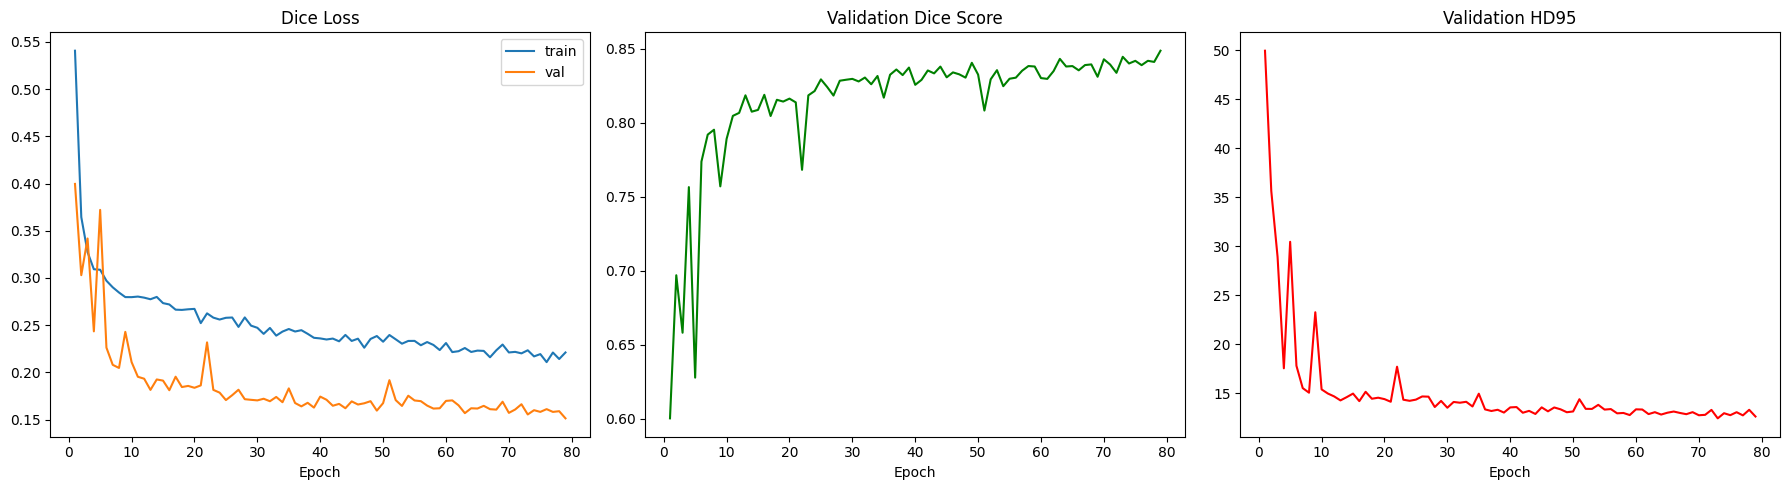

In [1]:
%matplotlib inline
# ════════════════════════════════════════════════════════════════
# PLOT TRAINING METRICS FROM SAVED CHECKPOINT (LAPTOP LOCAL)
# ════════════════════════════════════════════════════════════════
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# Absolute path to your checkpoint
ckpt_path = Path(r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/UNET_Segmentation/3DBreastnet/checkpoints_3d/3dbreastnet_best.pth")

if ckpt_path.exists():
    print(f"Loading checkpoint: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    hist = ckpt["hist"]
    
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    ax[0].plot(hist["epoch"], hist["train_loss"], label="train")
    ax[0].plot(hist["epoch"], hist["val_loss"], label="val")
    ax[0].set_title("Dice Loss"); ax[0].legend()
    
    ax[1].plot(hist["epoch"], hist["val_dice"], color="green")
    ax[1].set_title("Validation Dice Score")
    
    ax[2].plot(hist["epoch"], hist["val_hd"], color="red")
    ax[2].set_title("Validation HD95")
    
    for a in ax: a.set_xlabel("Epoch")
    plt.tight_layout()
    plt.show()
else:
    print(f"Checkpoint not found at {ckpt_path}.")


### Fine Tuning

## Post-Training 3D Visualization (Local Laptop)
Run this cell to perform inference using explicit local Windows paths.

In [ ]:
# ════════════════════════════════════════════════════════════════
# 3D VISUALIZATION OF RANDOM PATIENTS (LAPTOP LOCAL)
# ════════════════════════════════════════════════════════════════
import random
import io
from IPython.display import display, Image
import torch
from pathlib import Path
from skimage.measure import marching_cubes
from scipy.ndimage import gaussian_filter
import plotly.graph_objects as go

# NOTE: All classes (UNet, Encoder2D, Decoder3D, PatientDataset, build_patient_groups)
# are defined in earlier cells. Make sure to run those cells first.

def visualize_random_patients_local(n=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Hardcoded Absolute Paths for your Laptop
    unet_ckpt = r"../../UNET_Segmentation/breast_segmentation_unet_best_gpu.pth"
    tiff_base = r"../../data/organized_by_patient"
    ckpt_path = Path(r"../../UNET_Segmentation/3DBreastnet/checkpoints_3d/3dbreastnet_best.pth")
    
    if not ckpt_path.exists():
        print(f"Error: No trained model found at {ckpt_path}.")
        return
        
    print("Loading checkpoints...")
    
    unet = UNet().to(device)
    unet.load_state_dict(torch.load(unet_ckpt, map_location=device, weights_only=False))
    unet.eval()
    
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    enc = Encoder2D().to(device)
    dec = Decoder3D().to(device)
    enc.load_state_dict(ckpt["enc"])
    dec.load_state_dict(ckpt["dec"])
    enc.eval(); dec.eval()
    
    print(f"Loading patient list from {tiff_base}...")
    groups = build_patient_groups(tiff_base)
    if len(groups) == 0: 
        print("No patients found. Check dataset path.")
        return
    
    selected = random.sample(groups, min(n, len(groups)))
    dataset = PatientDataset(selected, unet, device)
    
    print(f"Generating 3D models for {len(selected)} patients...")
    
    for i in range(len(dataset)):
        item = dataset[i]
        pid, label = item["patient_id"], item["label"]
        m5 = item["masks_5ch"].unsqueeze(0).to(device)
        
        with torch.no_grad(), torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            vol = dec(enc(m5))
        vol_np = vol[0, 0].cpu().numpy()
        vol_np = gaussian_filter(vol_np, sigma=1.0)
        
        try:
            verts, faces, normals, values = marching_cubes(vol_np, level=0.5)
            fig = go.Figure(data=[
                go.Mesh3d(
                    x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
                    i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
                    colorscale='Hot',
                    intensity=verts[:, 2],
                    showscale=False
                )
            ])
            fig.update_layout(
                title=f"Patient: {pid} | Label: {label} (3D Reconstruction)",
                scene=dict(
                    xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
                    aspectmode='data'
                ),
                margin=dict(l=0, r=0, b=0, t=40)
            )
            fig.show()
        except ValueError:
            print(f"Could not generate 3D mesh for {pid} (volume might be empty).")

# Run it!
visualize_random_patients_local(n=5)

Using device: cuda
Loading checkpoints...
Loading patient list from ../../data/organized_by_patient...
  Skip Patient_384 (malignant): 4/5 views
  Skip Patient_23 (benign): 3/5 views
  Skip Patient_141 (benign): 4/5 views
  Skip Patient_109 (benign): 4/5 views
  Skip Patient_394 (malignant): 4/5 views
  Skip Patient_160 (benign): 4/5 views
  Skip Patient_163 (benign): 4/5 views
  Skip Patient_18 (benign): 2/5 views
  Skip Patient_104 (benign): 1/5 views
  Skip Patient_258 (malignant): 4/5 views
  Skip Patient_105 (benign): 1/5 views
  Skip Patient_189 (benign): 2/5 views
  Skip Patient_51 (benign): 4/5 views
  Skip Patient_243 (benign): 4/5 views
  Skip Patient_193 (benign): 2/5 views
Patients: 137 | Complete: 122 | Skipped: 15 | B=96 M=26
Generating 3D models for 5 patients...


RuntimeError: array type dtype('float16') not supported

## Export Geometry (.STL)
Run this cell to batch process **all available patients** through the network and export their 3D reconstructed geometries into universally readable `.stl` files. You can open these in Blender, MeshLab, or Windows 3D Viewer.

In [ ]:
# ════════════════════════════════════════════════════════════════
import os
import struct
import torch
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm
from scipy.ndimage import binary_closing, binary_fill_holes, generate_binary_structure, label, gaussian_filter
from skimage.measure import marching_cubes

# NOTE: All classes (UNet, Encoder2D, Decoder3D, PatientDataset, build_patient_groups)
# are defined in earlier cells. Make sure to run those cells first.


def clean_volume_for_export(volume, threshold=0.35):
    """Convert the raw prediction into a closed binary volume before meshing."""
    mask = volume >= threshold
    structure = generate_binary_structure(3, 2)

    # Fill gaps and seal small openings so the exported mesh is watertight.
    mask = binary_closing(mask, structure=structure, iterations=1)
    mask = binary_fill_holes(mask)

    labeled, num = label(mask, structure=structure)
    if num > 1:
        sizes = np.bincount(labeled.ravel())
        sizes[0] = 0
        mask = labeled == sizes.argmax()

    # Pad one voxel so marching_cubes can build a closed outer shell.
    mask = np.pad(mask, 1, mode="constant", constant_values=False)
    return mask.astype(np.float32)


def save_stl(filename, verts, faces):
    """Writes a binary STL file natively without needing external libraries."""
    with open(filename, "wb") as f:
        # 80 byte header
        f.write(b"\0" * 80)
        # Number of triangles (uint32)
        f.write(struct.pack("<I", len(faces)))

        for face in faces:
            tri = verts[face].astype(np.float32, copy=False)
            v0, v1, v2 = tri
            normal = np.cross(v1 - v0, v2 - v0)
            norm = np.linalg.norm(normal)
            if norm > 0:
                normal = (normal / norm).astype(np.float32, copy=False)
            else:
                normal = np.zeros(3, dtype=np.float32)

            f.write(struct.pack("<3f", *normal))
            f.write(struct.pack("<3f", *v0))
            f.write(struct.pack("<3f", *v1))
            f.write(struct.pack("<3f", *v2))
            # Attribute byte count (uint16)
            f.write(struct.pack("<H", 0))


def export_all_patients_to_stl():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Setup Output Directory
    out_dir = Path("exported_stls")
    out_dir.mkdir(exist_ok=True)

    unet_ckpt = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/UNET_Segmentation/breast_segmentation_unet_best_gpu.pth"
    tiff_base = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/organized_by_patient"
    ckpt_path = Path(r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/UNET_Segmentation/3DBreastnet/checkpoints_3d/3dbreastnet_best.pth")

    if not ckpt_path.exists():
        print(f"Error: No trained model found at {ckpt_path}.")
        return

    print("Loading checkpoints...")
    unet = UNet().to(device)
    unet.load_state_dict(torch.load(unet_ckpt, map_location=device, weights_only=False))
    unet.eval()

    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    enc = Encoder2D().to(device)
    dec = Decoder3D().to(device)
    enc.load_state_dict(ckpt["enc"])
    dec.load_state_dict(ckpt["dec"])
    enc.eval(); dec.eval()

    groups = build_patient_groups(tiff_base)
    if not groups:
        return

    dataset = PatientDataset(groups, unet, device)

    print(f"Batch exporting {len(dataset)} patients to .STL...")

    for i in tqdm(range(len(dataset))):
        item = dataset[i]
        pid = item["patient_id"]
        m5 = item["masks_5ch"].unsqueeze(0).to(device)

        with torch.no_grad(), torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            vol = dec(enc(m5)).float()
            
        vol_np = vol[0, 0].cpu().numpy()
        
        # 1. Pad the volume with 0s on all boundaries to force a closed, watertight solid!
        vol_np = np.pad(vol_np, pad_width=1, mode='constant', constant_values=0)
        
        # 2. Apply stronger Gaussian smoothing to eliminate the voxel staircasing (sigma=2.0)
        vol_np = gaussian_filter(vol_np, sigma=2.0)
        
        try:
            verts, faces, normals, _ = marching_cubes(vol_np, level=0.5)
            # 3. Shift vertices back by 1 to compensate for the padding
            verts = verts - 1.0
            
            # Scale coordinates relative to [-1, 1] for sane mesh sizes in external viewers
            verts = (verts / 63.5) - 1.0
            
            # Export
            export_path = out_dir / f"{pid}_3d_geometry.stl"
            save_stl(export_path, verts, faces)
        except Exception as e:
            print(f"Skipping {pid} due to error: {e}")

    print(f"\nSuccess! All meshes have been saved to the '{out_dir.absolute()}' directory.")


# Run the batch exporter
export_all_patients_to_stl()

Loading checkpoints...
  Skip Patient_384 (malignant): 4/5 views
  Skip Patient_23 (benign): 3/5 views
  Skip Patient_141 (benign): 4/5 views
  Skip Patient_109 (benign): 4/5 views
  Skip Patient_394 (malignant): 4/5 views
  Skip Patient_160 (benign): 4/5 views
  Skip Patient_163 (benign): 4/5 views
  Skip Patient_18 (benign): 2/5 views
  Skip Patient_104 (benign): 1/5 views
  Skip Patient_258 (malignant): 4/5 views
  Skip Patient_105 (benign): 1/5 views
  Skip Patient_189 (benign): 2/5 views
  Skip Patient_51 (benign): 4/5 views
  Skip Patient_243 (benign): 4/5 views
  Skip Patient_193 (benign): 2/5 views
Patients: 137 | Complete: 122 | Skipped: 15 | B=96 M=26
Batch exporting 122 patients to .STL...


  0%|          | 0/122 [00:00<?, ?it/s]

Skipping Patient_1 due to error: save_stl() takes 3 positional arguments but 4 were given
Skipping Patient_10 due to error: save_stl() takes 3 positional arguments but 4 were given
Skipping Patient_100 due to error: save_stl() takes 3 positional arguments but 4 were given
Skipping Patient_106 due to error: save_stl() takes 3 positional arguments but 4 were given
Skipping Patient_107 due to error: save_stl() takes 3 positional arguments but 4 were given
Skipping Patient_108 due to error: save_stl() takes 3 positional arguments but 4 were given
Skipping Patient_110 due to error: save_stl() takes 3 positional arguments but 4 were given
Skipping Patient_111 due to error: save_stl() takes 3 positional arguments but 4 were given
Skipping Patient_113 due to error: save_stl() takes 3 positional arguments but 4 were given
Skipping Patient_115 due to error: save_stl() takes 3 positional arguments but 4 were given
Skipping Patient_116 due to error: save_stl() takes 3 positional arguments but 4 we

KeyboardInterrupt: 

## Test Single Patient STL Export
Run this cell to quickly generate and test the `.stl` output for a specific patient without batch processing the whole dataset.

In [ ]:
import struct
import torch
import numpy as np
from scipy.ndimage import gaussian_filter
from skimage.measure import marching_cubes

# NOTE: All classes (UNet, Encoder2D, Decoder3D, PatientDataset, build_patient_groups)
# are defined in earlier cells. Make sure to run those cells first.

def save_stl(filename, verts, faces, normals):
    with open(filename, "wb") as f:
        f.write(b"\0" * 80)
        f.write(struct.pack("<I", len(faces)))
        for face in faces:
            f.write(struct.pack("<3f", 0.0, 0.0, 0.0))
            f.write(struct.pack("<3f", *verts[face[0]]))
            f.write(struct.pack("<3f", *verts[face[1]]))
            f.write(struct.pack("<3f", *verts[face[2]]))
            f.write(struct.pack("<H", 0))

def export_all_patients_to_stl():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    out_dir = Path("exported_stls")
    out_dir.mkdir(exist_ok=True)
    
    unet_ckpt = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/UNET_Segmentation/breast_segmentation_unet_best_gpu.pth"
    tiff_base = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/organized_by_patient"
    ckpt_path = Path(r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/UNET_Segmentation/3DBreastnet/checkpoints_3d/3dbreastnet_best.pth")
    
    if not ckpt_path.exists():
        print(f"Error: Checkpoint not found at {ckpt_path}.")
        return
        
    print("Loading checkpoints...")
    unet = UNet().to(device)
    unet.load_state_dict(torch.load(unet_ckpt, map_location=device, weights_only=False))
    unet.eval()
    
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    enc = Encoder2D().to(device)
    dec = Decoder3D().to(device)
    enc.load_state_dict(ckpt["enc"])
    dec.load_state_dict(ckpt["dec"])
    enc.eval(); dec.eval()
    
    groups = build_patient_groups(tiff_base)
    if not groups:
        print("No complete patients found in the dataset.")
        return
        
    dataset = PatientDataset(groups, unet, device)
    print(f"Batch exporting {len(dataset)} patients to .STL...")
    
    for item in dataset:
        pid = item["patient_id"]
        m5 = item["masks_5ch"].unsqueeze(0).to(device)
        
        with torch.no_grad(), torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            vol = dec(enc(m5)).float()
            
        vol_np = vol[0, 0].cpu().numpy()
        vol_np = np.pad(vol_np, pad_width=1, mode='constant', constant_values=0)
        vol_np = gaussian_filter(vol_np, sigma=2.0)
        
        try:
            verts, faces, normals, _ = marching_cubes(vol_np, level=0.5)
            verts = verts - 1.0
            verts = (verts / 63.5) - 1.0
            
            export_path = out_dir / f"{pid}_3d_geometry.stl"
            save_stl(export_path, verts, faces, normals)
            print(f"Exported {pid} -> {export_path}")
        except Exception as e:
            print(f"Skipping {pid} due to error: {e}")

    print(f"\nSuccess! All meshes have been saved to the '{out_dir.absolute()}' directory.")

# Run the batch exporter
export_all_patients_to_stl()

Loading checkpoints...
  Skip Patient_384 (malignant): 4/5 views
  Skip Patient_23 (benign): 3/5 views
  Skip Patient_141 (benign): 4/5 views
  Skip Patient_109 (benign): 4/5 views
  Skip Patient_394 (malignant): 4/5 views
  Skip Patient_160 (benign): 4/5 views
  Skip Patient_163 (benign): 4/5 views
  Skip Patient_18 (benign): 2/5 views
  Skip Patient_104 (benign): 1/5 views
  Skip Patient_258 (malignant): 4/5 views
  Skip Patient_105 (benign): 1/5 views
  Skip Patient_189 (benign): 2/5 views
  Skip Patient_51 (benign): 4/5 views
  Skip Patient_243 (benign): 4/5 views
  Skip Patient_193 (benign): 2/5 views
Patients: 137 | Complete: 122 | Skipped: 15 | B=96 M=26
Batch exporting 122 patients to .STL...
Exported Patient_1 -> exported_stls/Patient_1_3d_geometry.stl
Exported Patient_10 -> exported_stls/Patient_10_3d_geometry.stl
Exported Patient_100 -> exported_stls/Patient_100_3d_geometry.stl
Exported Patient_106 -> exported_stls/Patient_106_3d_geometry.stl
Exported Patient_107 -> exported

## Per Patient Projection Validation on Each View

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

# Import model architectures and data loaders from your existing scripts
from models import UNet, Encoder2D, Decoder3D
from train import build_patient_groups, PatientDataset, dice_loss, render_projection

def evaluate_all_patients():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # 1. Setup Directories
    out_dir = Path("projection_plots")
    out_dir.mkdir(exist_ok=True)
    
    # 2. Paths
    base_dir = Path("../..").resolve()
    unet_ckpt = base_dir / "UNET_Segmentation" / "breast_segmentation_unet_best_gpu.pth"
    tiff_base = base_dir / "data" / "organized_by_patient"
    ckpt_path = Path("checkpoints_3d/3dbreastnet_best.pth")
    
    # 3. Load Models
    print("Loading checkpoints...")
    unet = UNet().to(device)
    unet.load_state_dict(torch.load(unet_ckpt, map_location=device, weights_only=False))
    unet.eval()
    
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    enc = Encoder2D().to(device)
    dec = Decoder3D().to(device)
    enc.load_state_dict(ckpt["enc"])
    dec.load_state_dict(ckpt["dec"])
    enc.eval(); dec.eval()
    
    # 4. Load Data
    groups = build_patient_groups(tiff_base)
    if not groups:
        print("No patients found.")
        return
    dataset = PatientDataset(groups, unet, device)
    
    # 5. Evaluation Loop
    view_angles = [-90.0, -45.0, 0.0, 45.0, 90.0]
    view_names = ["Right Lateral (-90°)", "Right Oblique (-45°)", "Frontal (0°)", "Left Oblique (45°)", "Left Lateral (90°)"]
    
    all_dices = []
    
    print(f"\nEvaluating {len(dataset)} patients and generating 2x5 plots...")
    
    for item in tqdm(dataset):
        pid = item["patient_id"]
        m5 = item["masks_5ch"].unsqueeze(0).to(device)  # Ground Truth 2D Silhouettes [1, 5, 128, 128]
        
        with torch.no_grad(), torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            # Generate 3D Volume
            vol = dec(enc(m5)).float()
            
            patient_dices = []
            projections = []
            
            # Render and Calculate Dice for the 5 standard angles
            for i, angle in enumerate(view_angles):
                th = torch.tensor([angle], device=device, dtype=torch.float32)
                proj = render_projection(vol, th)  # [1, 1, 128, 128]
                
                gt_mask = m5[:, i:i+1] # [1, 1, 128, 128]
                dl = dice_loss(proj, gt_mask)
                d_score = 1.0 - dl.item()
                
                patient_dices.append(d_score)
                # Binarize the projection at 0.5 threshold to see the sharp silhouette curves
                binary_proj = (proj[0, 0] > 0.5).cpu().numpy().astype(np.float32)
                projections.append(binary_proj)
        
        all_dices.append(np.mean(patient_dices))
        
        # 6. Generate 2x5 Grid Plot
        fig, axes = plt.subplots(2, 5, figsize=(20, 8))
        fig.suptitle(f"Patient: {pid} | Average Dice Score: {np.mean(patient_dices):.4f}", fontsize=16)
        
        for i in range(5):
            # Top Row: Ground Truth (U-Net mask)
            gt_img = m5[0, i].cpu().numpy()
            axes[0, i].imshow(gt_img, cmap='gray')
            axes[0, i].set_title(f"GT: {view_names[i]}")
            axes[0, i].axis('off')
            
            # Bottom Row: 3D Projected Silhouette
            axes[1, i].imshow(projections[i], cmap='gray')
            axes[1, i].set_title(f"Predicted Projection (Dice: {patient_dices[i]:.3f})")
            axes[1, i].axis('off')
            
        plt.tight_layout()
        plot_path = out_dir / f"{pid}_validation_grid.png"
        plt.savefig(plot_path, dpi=150)
        plt.close(fig)
        
    # 7. Final Results
    overall_mean = np.mean(all_dices)
    overall_std = np.std(all_dices)
    
    print("\n" + "="*50)
    print("FINAL VALIDATION RESULTS (Test on All Patients)")
    print("="*50)
    print(f"Total Patients Evaluated : {len(dataset)}")
    print(f"Overall Mean Dice Score  : {overall_mean:.4f}")
    print(f"Standard Deviation       : {overall_std:.4f}")
    print(f"Validation plots saved in: {out_dir.absolute()}")

if __name__ == "__main__":
    evaluate_all_patients()

Using device: cpu
Loading checkpoints...
  Skip Patient_104 (benign): 1/5 views
  Skip Patient_105 (benign): 1/5 views
  Skip Patient_109 (benign): 4/5 views
  Skip Patient_141 (benign): 4/5 views
  Skip Patient_160 (benign): 4/5 views
  Skip Patient_163 (benign): 4/5 views
  Skip Patient_18 (benign): 2/5 views
  Skip Patient_189 (benign): 2/5 views
  Skip Patient_193 (benign): 2/5 views
  Skip Patient_23 (benign): 3/5 views
  Skip Patient_243 (benign): 4/5 views
  Skip Patient_258 (malignant): 4/5 views
  Skip Patient_384 (malignant): 4/5 views
  Skip Patient_394 (malignant): 4/5 views
  Skip Patient_51 (benign): 4/5 views
Patients: 137 | Complete: 122 | Skipped: 15 | B=96 M=26

Evaluating 122 patients and generating 2x5 plots...


  0%|          | 0/122 [00:00<?, ?it/s]

KeyboardInterrupt: 